# 2 线性代数和 NDArray

## 2.1 理论计算题

已知：向量 $a = [2, -1, 3]^\top$，$b = [1, 4, -2]^\top$，矩阵 $A = \begin{bmatrix} 1 & 0 & 2 \\ -1 & 3 & 1 \end{bmatrix}$，$B = \begin{bmatrix} 2 & 1 \\ 0 & -1 \\ 3 & 2 \end{bmatrix}$

### 1. 向量点积 $a \cdot b$

点积公式：对应位置相乘后相加

$$
a \cdot b = 2 \times 1 + (-1) \times 4 + 3 \times (-2) = 2 - 4 - 6 = -8
$$

### 2. 矩阵乘法 $A \times B$

矩阵乘法规则：左矩阵的行 × 右矩阵的列，对应相乘后求和

第一行第一列：$1 \times 2 + 0 \times 0 + 2 \times 3 = 2 + 0 + 6 = 8$

第一行第二列：$1 \times 1 + 0 \times (-1) + 2 \times 2 = 1 + 0 + 4 = 5$

第二行第一列：$-1 \times 2 + 3 \times 0 + 1 \times 3 = -2 + 0 + 3 = 1$

第二行第二列：$-1 \times 1 + 3 \times (-1) + 1 \times 2 = -1 - 3 + 2 = -2$

结果：

$$
AB = \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix}, \quad \text{形状：} 2 \times 2
$$

### 3. 向量 $a$ 的 Frobenius 范数

范数公式：各元素平方和开根号

$$
\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14} \approx 3.7417
$$

---

In [5]:
import numpy as np
np.random.seed(42)

# 1. 3×4 标准正态矩阵
X = np.random.randn(3, 4)
print("X =\n", X)

# 2. 4×2 全1矩阵
Y = np.ones((4, 2))
print("\nY =\n", Y)

# 3. 矩阵乘法
Z = X @ Y
print("\nZ =\n", Z)

# 4. 取值
print("\nZ[0,1] =", Z[0, 1])
print("Z[1,:] =", Z[1, :])

# 5. Frobenius 范数
print("\n||Z||_F =", np.linalg.norm(Z))

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z[0,1] = 2.5291682463487657
Z[1,:] = [1.87835721 1.87835721]

||Z||_F = 4.616873319476863


## 3.1 贝叶斯公式

已知：患病率 $P(D) = 0.001$，灵敏度 $P(T^+|D) = 0.99$，假阳性率 $P(T^+|\neg D) = 0.02$

由贝叶斯公式：

$$
P(D|T^+) = \frac{P(T^+|D)P(D)}{P(T^+|D)P(D) + P(T^+|\neg D)P(\neg D)}
$$

代入：

$$
P(D|T^+) = \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999} = \frac{0.00099}{0.02097} \approx 0.0472 = 4.72\%
$$

---

均值方差 = 8.314169733144293e-06


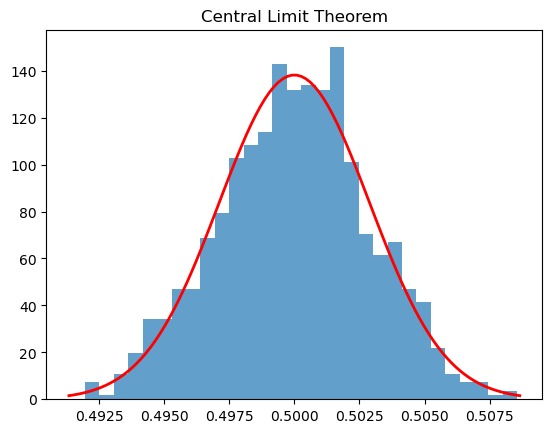

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 10000
m = 1000
means = [np.mean(np.random.uniform(0,1,n)) for _ in range(m)]

print("均值方差 =", np.var(means))

plt.hist(means, bins=30, density=True, alpha=0.7)
mu, sigma = 0.5, np.sqrt(1/(12*n))
x = np.linspace(mu-3*sigma, mu+3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
plt.title("Central Limit Theorem")
plt.show()

## 4.1 理论计算题：求梯度

已知：$z = (w_1 x_1 + w_2 x_2 - y)^2$

给定：$x_1 = 2$，$x_2 = 1$，$y = 3$，$w_1 = 0.5$，$w_2 = 1$

### 1. 求偏导公式（链式法则）

$$
\frac{\partial z}{\partial w_1} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1 = 2x_1(w_1 x_1 + w_2 x_2 - y)
$$

$$
\frac{\partial z}{\partial w_2} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2 = 2x_2(w_1 x_1 + w_2 x_2 - y)
$$

### 2. 代入数值计算

先算括号内：

$$
w_1 x_1 + w_2 x_2 - y = 0.5 \times 2 + 1 \times 1 - 3 = 1 + 1 - 3 = -1
$$

然后：

$$
\frac{\partial z}{\partial w_1} = 2 \times 2 \times (-1) = -4
$$

$$
\frac{\partial z}{\partial w_2} = 2 \times 1 \times (-1) = -2
$$

最终梯度：$[-4, -2]$

---


In [7]:
# 手动
x, w1, w2 = 2, 1.5, 0.5
a = x*w1
b = a+w2
L = b**2
dL_dw1 = 2*b*x
dL_dw2 = 2*b
print("手动梯度：", dL_dw1, dL_dw2)

# PyTorch 验证
import torch
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)
L = (2*w1 + w2)**2
L.backward()
print("自动梯度：", w1.grad.item(), w2.grad.item())

手动梯度： 14.0 7.0
自动梯度： 14.0 7.0


## 5.1 线性回归 MSE 损失偏导

模型：$y = wx + b$，均方误差损失：

$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2
$$

### 对 $w$ 求偏导

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - wx_i - b) \cdot (-x_i) = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - wx_i - b)
$$

### 对 $b$ 求偏导

$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - wx_i - b) \cdot (-1) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - wx_i - b)
$$

---

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

digits = load_digits()
X = digits.data / 16
y = digits.target

y_onehot = np.zeros((len(y),10))
y_onehot[range(len(y)),y] = 1

X_train,X_test,y_train,y_test = train_test_split(X,y_onehot,test_size=0.2)

def softmax(z):
    e = np.exp(z - z.max(1,keepdims=True))
    return e / e.sum(1,keepdims=True)

W = np.zeros((64,10))
b = np.zeros(10)
lr = 0.1
epochs = 50
bs = 32

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    for i in range(0,len(X_train),bs):
        xb = X_train[idx[i:i+bs]]
        yb = y_train[idx[i:i+bs]]
        yp = softmax(xb@W + b)
        dz = yp - yb
        W -= lr * xb.T@dz / len(xb)
        b -= lr * dz.mean(0)

yp = softmax(X_test@W + b)
acc = accuracy_score(np.argmax(y_test,1), np.argmax(yp,1))
print("测试准确率：", acc)

测试准确率： 0.95


## 6.1 正态分布的最大似然估计

样本 $x_1, x_2, \ldots, x_n$ 独立同分布于 $\mathcal{N}(\mu, \sigma^2)$

### 1. 似然函数

$$
L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2\right)
$$

### 2. $\mu$ 的最大似然估计

$$
\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0 \Rightarrow \sum x_i - n\mu = 0 \Rightarrow \hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

### 3. $\sigma^2$ 的最大似然估计

$$
\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum (x_i - \mu)^2 = 0 \Rightarrow \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
$$

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score

np.random.seed(42)
X1 = np.random.randn(200,2) + [2,2]
X2 = np.random.randn(200,2) + [-2,-2]
X = np.vstack([X1,X2])
y = np.hstack([np.ones(200),np.zeros(200)])

def sigmoid(z):
    return 1/(1+np.exp(-z))

w = np.zeros(2)
b = 0
lr = 0.1

for _ in range(1000):
    yp = sigmoid(X@w + b)
    w -= lr * X.T@(yp-y)/len(X)
    b -= lr * (yp-y).mean()

# 测试
Xt = np.vstack([np.random.randn(50,2)+[2,2], np.random.randn(50,2)+[-2,-2]])
yt = np.hstack([np.ones(50),np.zeros(50)])
acc = accuracy_score(yt, (sigmoid(Xt@w+b)>=0.5).astype(int))
print("测试准确率：", acc)

测试准确率： 1.0
